## Veri Bilimi Final Ödevi

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


## 1. Hangi kategori hem ticari performans hem de müşteri memnuniyeti açısından en güçlü görünüyor?

- Kategori bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.
- Kategori bazlı özet tablo oluşturun.
- Toplam gelir için bir bar plot çizdirin.
- Ortalama müşteri puanı için ikinci bir bar plot çizdirin.
- Hem gelir hem memnuniyet açısından en güçlü kategoriyi belirleyin ve kısa bir iş yorumu yazın.

In [ ]:
kategorik = (
    df.groupby("kategori")
    .agg({"siparis_id": "count",
          "toplam_tutar": "sum",
          "birim_fiyat": "mean",
          "musteri_puani": "mean",
          "teslimat_gunu": "mean"},

         )
    .round(2)
    .reset_index()
    )
kategorik

,kategori,siparis_id,toplam_tutar,birim_fiyat,musteri_puani,teslimat_gunu
0,Elektronik,140,212930.29,1065.50,4.24,3.32
1,Ev Yaşam,184,142335.55,366.69,4.26,3.45
2,Kitap,223,114075.59,224.80,4.25,3.42
3,Kozmetik,200,147522.90,373.58,4.42,3.35
4,Ofis,162,47051.88,138.25,4.24,3.13
5,Spor,186,189481.91,614.52,4.26,3.18


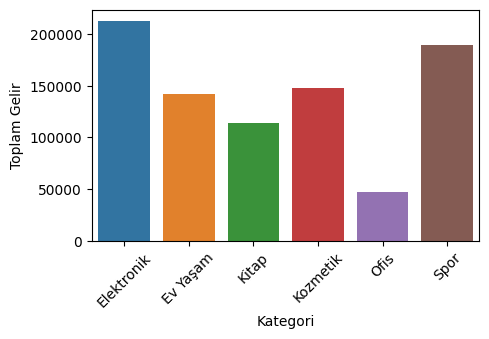

In [ ]:
plt.figure(figsize=(5, 3))
sns.barplot(data=kategorik, x="kategori", y="toplam_tutar", hue="kategori")
plt.xticks(rotation=45)
plt.xlabel("Kategori")
plt.ylabel("Toplam Gelir")
plt.show()

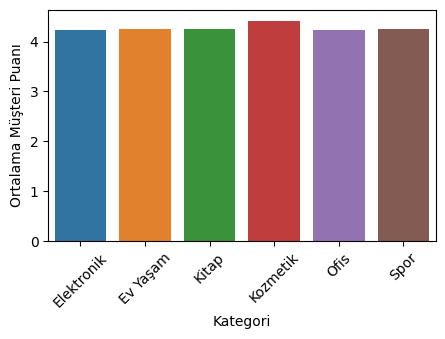

In [ ]:
plt.figure(figsize=(5, 3))
sns.barplot(data=kategorik, x="kategori", y="musteri_puani", hue="kategori")
plt.xticks(rotation=45)
plt.xlabel("Kategori")
plt.ylabel("Ortalama Müşteri Puanı")
plt.show()

In [ ]:
kategorik_ozet = (
    df.groupby("kategori")
    .agg(
        toplam_gelir=("toplam_tutar", "sum"),
        ort_puan=("musteri_puani", "mean")
    )
    .round(2)
    .reset_index()
)
en_guclu = kategorik_ozet.sort_values(by=["toplam_gelir", "ort_puan"], ascending=[False, False])
en_guclu

,kategori,toplam_gelir,ort_puan
0,Elektronik,212930.29,4.24
5,Spor,189481.91,4.26
3,Kozmetik,147522.90,4.42
1,Ev Yaşam,142335.55,4.26
2,Kitap,114075.59,4.25
4,Ofis,47051.88,4.24


Elektronik	en güçlü kategoridir çünkü :
- Açık ara gelir lideri
- Memnuniyet oranı yüksek ve istikrarlı

 ## 2. Hangi şehirler daha yüksek potansiyel taşıyor?

- Şehir bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.
- Şehir bazlı özet tablo oluşturun.
- Toplam gelire göre şehirleri büyükten küçüğe sıralayın.
- En güçlü 5 şehir için bir bar plot çizdirin.
- Müşteri puanı yüksek ama gelir açısından geride kalan şehirleri ayrıca tespit edin ve büyüme adayı şehirler için kısa bir yorum yazın.

In [ ]:
sehirsel = (
    df.groupby("sehir")
    .agg(siparis_sayisi=("siparis_id", "count"),
         toplam_gelir=("toplam_tutar", "sum"),
         ortalama_siparis_tutari=("birim_fiyat", "mean"),
         ortalama_musteri_puani=("musteri_puani", "mean"),
         )
    .round(2)
    .reset_index()
    )
sehirsel

,sehir,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
0,Adana,63,50353.28,441.52,4.33
1,Ankara,124,96721.13,458.43,4.19
2,Antalya,86,63712.80,366.45,4.28
3,Bursa,67,46782.83,349.47,4.21
4,Eskişehir,45,37550.04,470.23,4.24
5,Gaziantep,49,35240.29,443.47,4.35
6,Kayseri,36,24878.81,404.06,4.28
7,Kocaeli,31,21293.02,301.15,4.19
8,Konya,77,59424.33,511.60,4.36
9,Mersin,46,38043.87,420.53,4.22


In [ ]:
sehir_sıralama = (
    df.groupby("sehir")
    .agg({"toplam_tutar": "sum"})
    .sort_values(by="toplam_tutar", ascending=False)
    .reset_index()
)
sehir_sıralama

,sehir,toplam_tutar
0,İstanbul,224020.57
1,Ankara,96721.13
2,İzmir,88718.51
3,Antalya,63712.80
4,Konya,59424.33
5,Adana,50353.28
6,Bursa,46782.83
7,Mersin,38043.87
8,Eskişehir,37550.04
9,Samsun,36263.46


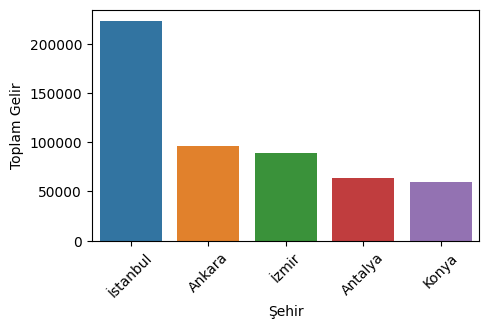

In [ ]:
plt.figure(figsize=(5, 3))
sns.barplot(data=sehir_sıralama.head(5), x="sehir", y="toplam_tutar", hue="sehir")
plt.xticks(rotation=45)
plt.xlabel("Şehir")
plt.ylabel("Toplam Gelir")
plt.show()

In [ ]:
potansiyelli_sehirler = (
    df.groupby("sehir")
    .agg(toplam_gelir=("toplam_tutar", "sum"),
         ortalama_musteri_puani=("musteri_puani", "mean"),)

    .round(2)
    .sort_values(by=["toplam_gelir","ortalama_musteri_puani"], ascending=[True, False])
    .reset_index())
potansiyelli_sehirler


,sehir,toplam_gelir,ortalama_musteri_puani
0,Kocaeli,21293.02,4.19
1,Kayseri,24878.81,4.28
2,Trabzon,30395.18,4.23
3,Gaziantep,35240.29,4.35
4,Samsun,36263.46,4.44
5,Eskişehir,37550.04,4.24
6,Mersin,38043.87,4.22
7,Bursa,46782.83,4.21
8,Adana,50353.28,4.33
9,Konya,59424.33,4.36


In [ ]:
ortalama_gelir = sehirsel["toplam_gelir"].mean()

potansiyelli_sehirler = sehirsel[
    (sehirsel["ortalama_musteri_puani"] >= 4.0) &
    (sehirsel["toplam_gelir"] < ortalama_gelir)
].sort_values(by="ortalama_musteri_puani", ascending=False).head(5)

potansiyelli_sehirler

,sehir,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
10,Samsun,45,36263.46,408.25,4.44
8,Konya,77,59424.33,511.60,4.36
5,Gaziantep,49,35240.29,443.47,4.35
0,Adana,63,50353.28,441.52,4.33
6,Kayseri,36,24878.81,404.06,4.28


Bu şehirlerde müşteri memnuniyeti yüksek (4.25+ puan) olmasına rağmen gelir henüz istenen seviyede değildir.

## 3. Hangi ödeme türü daha değerli müşteri davranışı üretiyor?

- Ödeme türü bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.
- Ödeme türüne göre özet tablo oluşturun.
- Ortalama sipariş tutarı için bir bar plot çizdirin.
- Ortalama müşteri puanı için ikinci bir bar plot çizdirin.
- En yüksek gelir üreten ödeme türü ile en yüksek memnuniyet üreten ödeme türünü karşılaştırın ve sonucu iş diliyle yorumlayın.

In [ ]:
odeme_bazinda = (
    df.groupby("odeme_turu")
    .agg(siparis_sayisi=("siparis_id", "count"),
         toplam_gelir=("toplam_tutar", "sum"),
         ortalama_siparis_tutari=("birim_fiyat","mean"),
         ortalama_musteri_puani=("musteri_puani", "mean"),
         ortalama_teslimat_günü=("teslimat_gunu", "mean"),)
    .round(2)
    .reset_index()
)
odeme_bazinda

,odeme_turu,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_günü
0,Banka Kartı,169,143011.08,481.14,4.24,3.53
1,Dijital Cüzdan,153,129911.25,444.58,4.27,3.27
2,Havale/EFT,111,92894.46,449.74,4.15,3.14
3,Kapıda Ödeme,79,48113.17,399.39,4.38,3.24
4,Kredi Kartı,583,439468.16,424.32,4.31,3.31


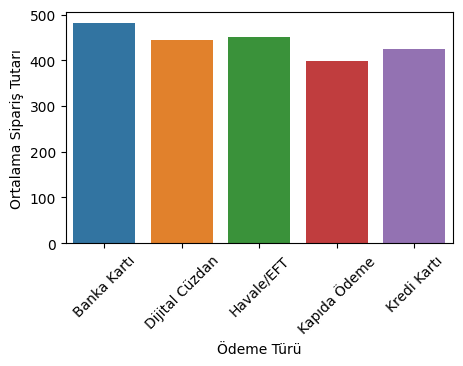

In [ ]:
plt.figure(figsize=(5, 3))
sns.barplot(data=odeme_bazinda, x="odeme_turu", y="ortalama_siparis_tutari", hue="odeme_turu")
plt.xticks(rotation=45)
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Sipariş Tutarı")
plt.show()

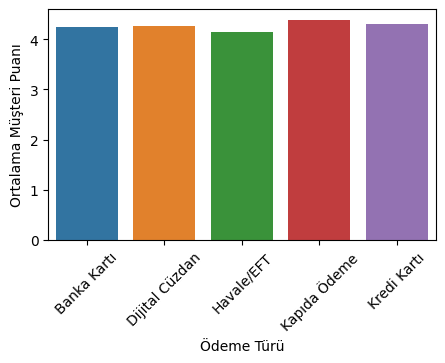

In [ ]:
plt.figure(figsize=(5, 3))
sns.barplot(data=odeme_bazinda, x="odeme_turu", y="ortalama_musteri_puani", hue="odeme_turu")
plt.xticks(rotation=45)
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Müşteri Puanı")
plt.show()

In [ ]:
en_yuksek_gelir = odeme_bazinda.sort_values(by="toplam_gelir", ascending=False).head(1)
en_yuksek_memnuniyet = odeme_bazinda.sort_values(by="ortalama_musteri_puani", ascending=False).head(1)
ozet_tablo = pd.concat([en_yuksek_gelir, en_yuksek_memnuniyet])
ozet_tablo

,odeme_turu,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_günü
4,Kredi Kartı,583,439468.16,424.32,4.31,3.31
3,Kapıda Ödeme,79,48113.17,399.39,4.38,3.24


- İşletmenin ana gelir kaynağı Kredi Kartı'dır.
- En yüksek müşteri memnuniyeti 4.38 puan ile Kapıda Ödeme seçeneğindedir.
- Kapıda ödeme seçeneğini koruyarak güven arayan müşterileri elde tutmalı, pazarlamayı ise cironun kalbi olan Kredi Kartı tarafına ağırlık vererek sürdürmeliyiz.

## 4. Zaman içinde satış davranışı nasıl değişiyor?

- siparis_tarihi sütununu uygun veri tipine dönüştürün.
- Ay bazında sipariş sayısı, toplam gelir ve ortalama sipariş tutarı metriklerini çıkarın.
- Sipariş sayısı için bir line plot çizdirin.
- Toplam gelir için ikinci bir line plot çizdirin.
- En yoğun ay ile en yüksek gelir elde edilen ayı karşılaştırın ve “sipariş artışı ile gelir artışı aynı dönemde mi gerçekleşiyor?” sorusuna yorum yapın.

In [ ]:
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_tarihi"].dtype

dtype('<M8[ns]')

In [ ]:
df["siparis_ay"] = df["siparis_tarihi"].dt.month


In [ ]:
ay_bazinda = (
    df.groupby("siparis_ay")
    .agg(siparis_sayisi=("siparis_id", "count"),
         toplam_gelir=("toplam_tutar", "sum"),
         ortalama_siparis_tutari=("birim_fiyat", "mean"),)
    .round(2)
    .reset_index()
)
ay_bazinda

,siparis_ay,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari
0,1,97,68309.45,477.23
1,2,84,67984.01,466.24
2,3,94,70857.89,455.75
3,4,111,68630.39,326.84
4,5,102,92213.41,441.98
5,6,85,77526.88,519.96
6,7,79,68774.62,480.07
7,8,80,55945.11,371.40
8,9,91,80591.62,511.32
9,10,89,60860.45,397.76


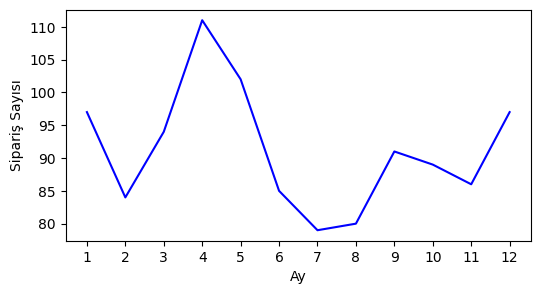

In [ ]:
plt.figure(figsize=(6, 3))
sns.lineplot(data=ay_bazinda, x="siparis_ay", y="siparis_sayisi", color="blue")
plt.xticks(ay_bazinda["siparis_ay"])
plt.xlabel("Ay")
plt.ylabel("Sipariş Sayısı")
plt.show()

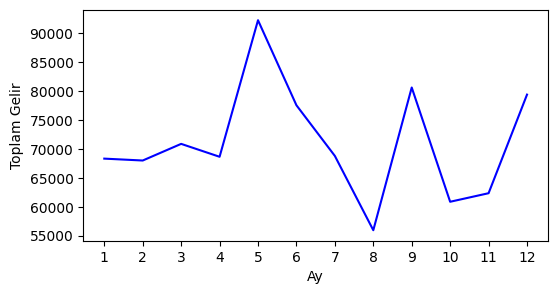

In [ ]:
plt.figure(figsize=(6, 3))
sns.lineplot(data=ay_bazinda, x="siparis_ay", y="toplam_gelir", color="blue")
plt.xticks(ay_bazinda["siparis_ay"])
plt.xlabel("Ay")
plt.ylabel("Toplam Gelir")
plt.show()

In [ ]:
en_yogun_ay = ay_bazinda.sort_values(by="siparis_sayisi", ascending=False).head(1)
en_yuksek_gelir = ay_bazinda.sort_values(by="toplam_gelir", ascending=False).head(1)

karsilastirma_tablo = pd.concat([en_yogun_ay, en_yuksek_gelir])
karsilastirma_tablo

,siparis_ay,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari
3,4,111,68630.39,326.84
4,5,102,92213.41,441.98


- Sipariş sayısındaki artış doğrudan en yüksek geliri getirmemiştir.
- Geliri belirleyen ana faktör sipariş adedinden ziyade
ortalama sipariş tutarı olmuştur.

## 5. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?

- sehir ve kategori kırılımında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.
- En güçlü 10 şehir-kategori kombinasyonunu bulun.
- Bu kombinasyonları göstermek için uygun bir bar plot oluşturun.
- En güçlü kombinasyonu belirleyin.
- Bu bulgunun pazarlama, kampanya veya ürün stratejisi açısından ne anlama gelebileceğini yorumlayın.

In [ ]:
sehir_kategori = (
    df.groupby(["sehir", "kategori"])
    .agg(
        toplam_gelir = ("toplam_tutar", "sum"),
        siparis_sayisi = ("siparis_id", "count"),
        ortalama_siparis_tutari = ("birim_fiyat", "mean"),
        ortalama_musteri_puani = ("musteri_puani", "mean"),
        )
    .round(2)
    .sort_values(["toplam_gelir"], ascending = False)
)
sehir_kategori

toplam_gelir  siparis_sayisi  ortalama_siparis_tutari  \
sehir     kategori                                                            
İstanbul  Elektronik      66731.92              45                  1035.37   
          Spor            53391.34              43                   671.19   
          Ev Yaşam        34130.59              43                   350.10   
          Kozmetik        33167.28              42                   359.49   
          Kitap           27106.12              56                   229.52   
...                            ...             ...                      ...   
Eskişehir Ofis             1727.90               6                   126.24   
Kayseri   Elektronik       1715.61               1                  1742.85   
Kocaeli   Ofis             1026.94               2                   172.01   
Kayseri   Ofis              868.53               3                   141.92   
Kocaeli   Elektronik        779.13               1                   788.66   

                      ortalama_musteri_puani  
sehir     kategori                            
İstanbul  Elektronik                    4.18  
          Spor                          4.33  
          Ev Yaşam                      4.42  
          Kozmetik                      4.55  
          Kitap                         4.29  
...                                      ...  
Eskişehir Ofis                          4.17  
Kayseri   Elektronik                    5.00  
Kocaeli   Ofis                          4.00  
Kayseri   Ofis                          4.00  
Kocaeli   Elektronik                    5.00  

[84 rows x 4 columns]

In [ ]:
en_guclu_10 = sehir_kategori.head(10).reset_index()

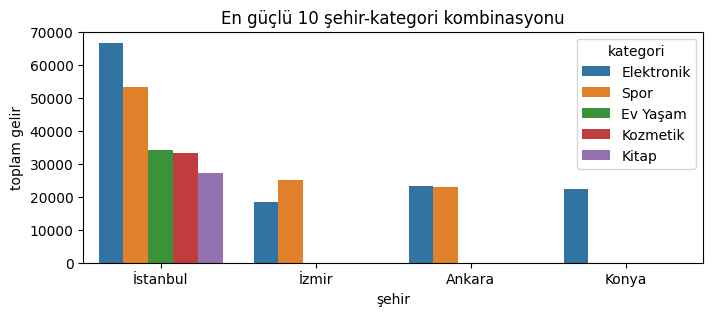

In [ ]:
plt.figure(figsize = (8,3))
sns.barplot(data = en_guclu_10, x = "sehir", y = "toplam_gelir", hue = "kategori")
plt.title("En güçlü 10 şehir-kategori kombinasyonu")
plt.xlabel("şehir")
plt.ylabel("toplam gelir")
plt.show()

In [ ]:
en_guclu_kombinasyon = en_guclu_10.iloc[0]
en_guclu_kombinasyon

,0
sehir,İstanbul
kategori,Elektronik
toplam_gelir,66731.92
siparis_sayisi,45
ortalama_siparis_tutari,1035.37
ortalama_musteri_puani,4.18


- En güçlü performans gösteren kombinasyon "İstanbul – Elektronik" ikilisidir. Bu ikili cironun amiral gemisi olmuştur.
- İstanbul'daki kitlenin teknolojik ürünlerde alım gücünün ve harcama eğiliminin yüksek olduğunu gösterir.
- Yüksek gelir getiren elektronik ürünlerin yanında koruyucu kılıf/kablo gibi aksesuarlar önerilerek çapraz satış fırsatları değerlendirilmelidir.
- Reklam ve dijital pazarlama bütçesinin önemli bir kısmı İstanbul bölgesindeki Elektronik aramalarına ayrılmalıdır.